<a href="https://colab.research.google.com/github/ShibleNK/is-cv/blob/main/eda_on_rice_pest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import os
import pandas as pd
import numpy as np

for dirname, _, filenames in os.walk('/content/drive/MyDrive/Pest_V2'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/content/drive/MyDrive/Pest_V2/brown plant hopper/adult/04451.jpg
/content/drive/MyDrive/Pest_V2/brown plant hopper/adult/04663.jpg
/content/drive/MyDrive/Pest_V2/brown plant hopper/adult/04865.jpg
/content/drive/MyDrive/Pest_V2/brown plant hopper/adult/04329.jpg
/content/drive/MyDrive/Pest_V2/brown plant hopper/adult/04776.jpg
/content/drive/MyDrive/Pest_V2/brown plant hopper/adult/04867.jpg
/content/drive/MyDrive/Pest_V2/brown plant hopper/adult/04551.jpg
/content/drive/MyDrive/Pest_V2/brown plant hopper/adult/04960.jpg
/content/drive/MyDrive/Pest_V2/brown plant hopper/adult/05064.jpg
/content/drive/MyDrive/Pest_V2/brown plant hopper/adult/04871.jpg
/content/drive/MyDrive/Pest_V2/brown plant hopper/adult/04861.jpg
/content/drive/MyDrive/Pest_V2/brown plant hopper/adult/04963.jpg
/content/drive/MyDrive/Pest_V2/brown plant hopper/adult/04458.jpg
/content/drive/MyDrive/Pest_V2/brown plant hopper/adult/05062.jpg
/content/drive/MyDrive/Pest_V2/brown plant hopper/adult/04670.jpg
/content/d

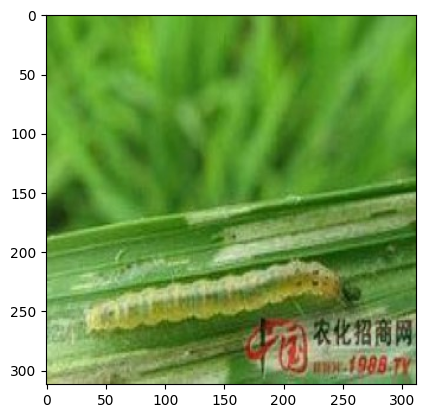

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as img

testImage = img.imread('/content/drive/MyDrive/Pest_V2/rice leaf roller/larva/00953.jpg')

# displaying the image
plt.imshow(testImage)

In [14]:
import cv2

# cv2.bilateralFilter(src, d, sigmaColor, sigmaSpace)
bilateral_filtered = cv2.bilateralFilter(testImage, d=5, sigmaColor=30, sigmaSpace=30)

array([[[ 75, 144,  28],
        [ 76, 145,  29],
        [ 78, 147,  31],
        ...,
        [104, 171,  55],
        [103, 170,  54],
        [103, 170,  54]],

       [[ 75, 144,  28],
        [ 76, 145,  29],
        [ 78, 147,  31],
        ...,
        [103, 170,  55],
        [103, 170,  54],
        [103, 170,  54]],

       [[ 75, 144,  29],
        [ 76, 145,  29],
        [ 78, 147,  31],
        ...,
        [103, 171,  55],
        [103, 170,  54],
        [103, 170,  54]],

       ...,

       [[167, 179, 110],
        [170, 183, 113],
        [175, 188, 118],
        ...,
        [118, 163, 109],
        [130, 170, 117],
        [133, 171, 119]],

       [[179, 191, 122],
        [182, 194, 125],
        [186, 197, 128],
        ...,
        [116, 161, 107],
        [129, 169, 116],
        [132, 171, 118]],

       [[180, 191, 122],
        [183, 194, 125],
        [187, 198, 129],
        ...,
        [116, 161, 107],
        [128, 168, 115],
        [131, 170, 118]]], dtype=uint8)
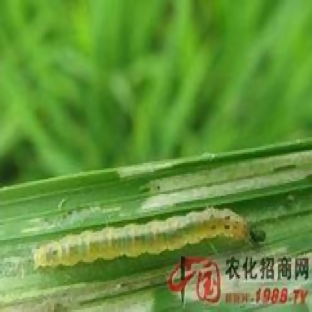

In [15]:
bilateral_filtered

In [16]:
# List to store all filtered images
original_image = []
bilateral_filtered = []


base_path = '/content/drive/MyDrive/Pest_V2'

for dirname, subdirs, filenames in os.walk(base_path):
    for filename in filenames:
        # Build full path
        img_path = os.path.join(dirname, filename)

        # Read the image as NumPy array
        img = cv2.imread(img_path)
        # Store in the original image dic
        original_image.append(img)
        if img is None:
            print(f"Failed to load: {img_path}")
            continue

        # Apply bilateral filter
        filtered = cv2.bilateralFilter(src=img, d=5, sigmaColor=30, sigmaSpace=30)

        # Store the result
        bilateral_filtered.append(filtered)


print(f"Processed {len(bilateral_filtered)} images successfully.")


Processed 1561 images successfully.


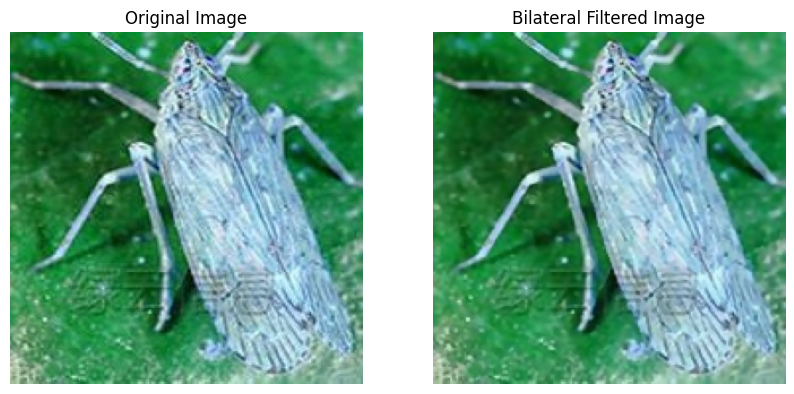

In [17]:

plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.imshow(original_image[150])
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(bilateral_filtered[150])
plt.title('Bilateral Filtered Image')
plt.axis('off')

plt.show()

Folder: /content/drive/MyDrive/Pest_V2/brown plant hopper/adult
Found: 335 images


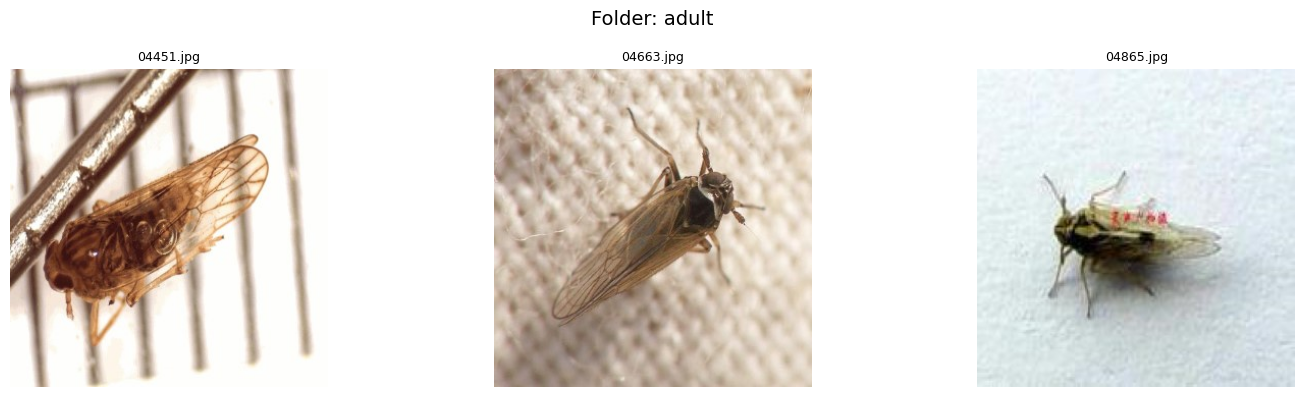

Folder: /content/drive/MyDrive/Pest_V2/brown plant hopper/eggs
Found: 7 images


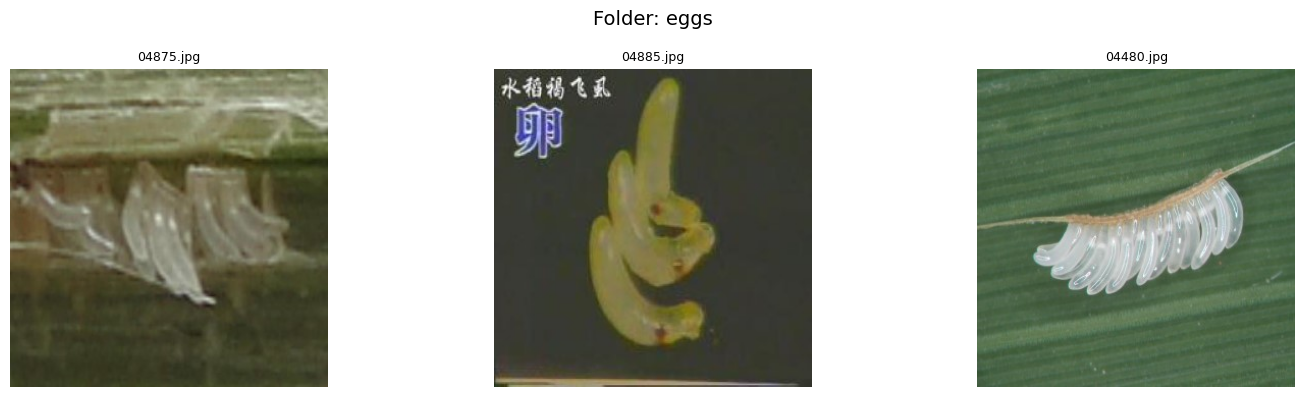

Folder: /content/drive/MyDrive/Pest_V2/brown plant hopper/larva
Found: 4 images


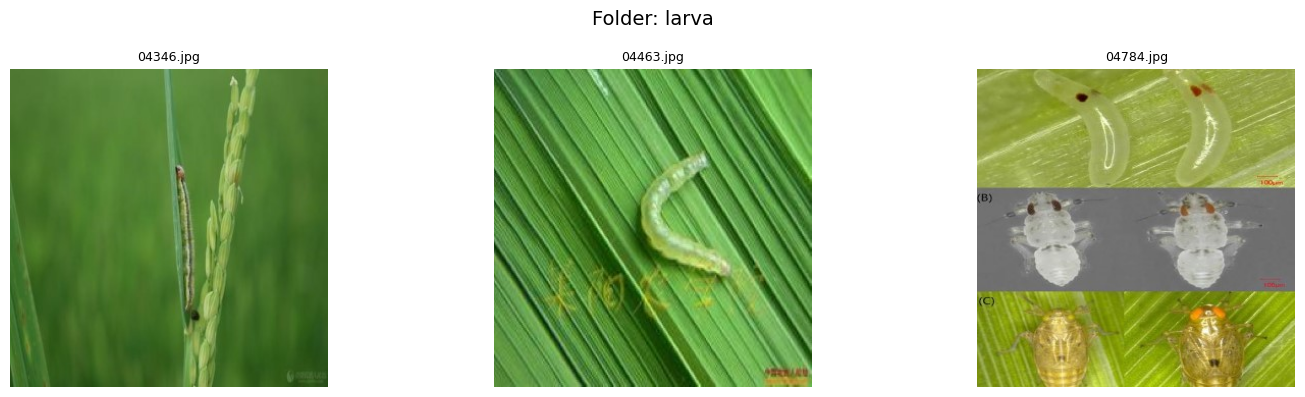

Folder: /content/drive/MyDrive/Pest_V2/asiatic rice borer/eggs
Found: 24 images


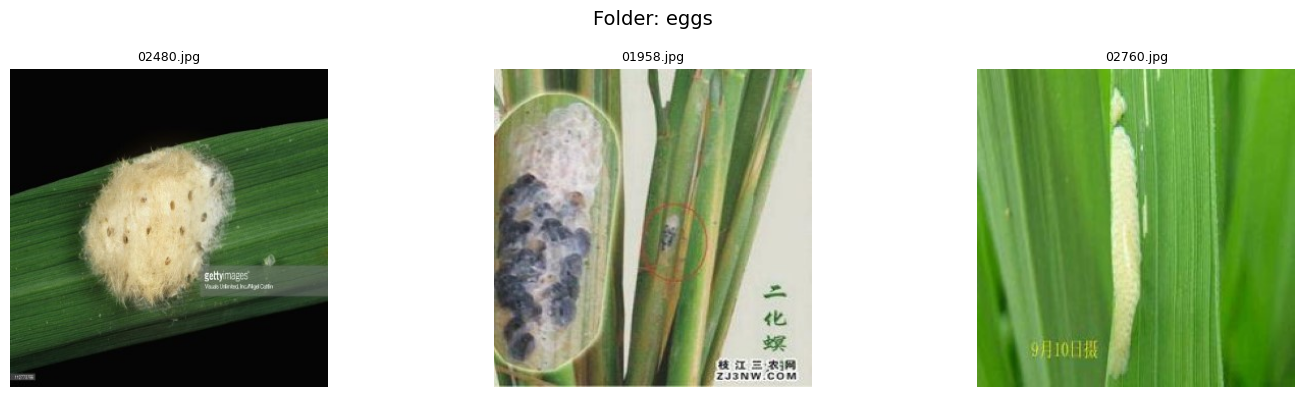

Folder: /content/drive/MyDrive/Pest_V2/asiatic rice borer/adult
Found: 155 images


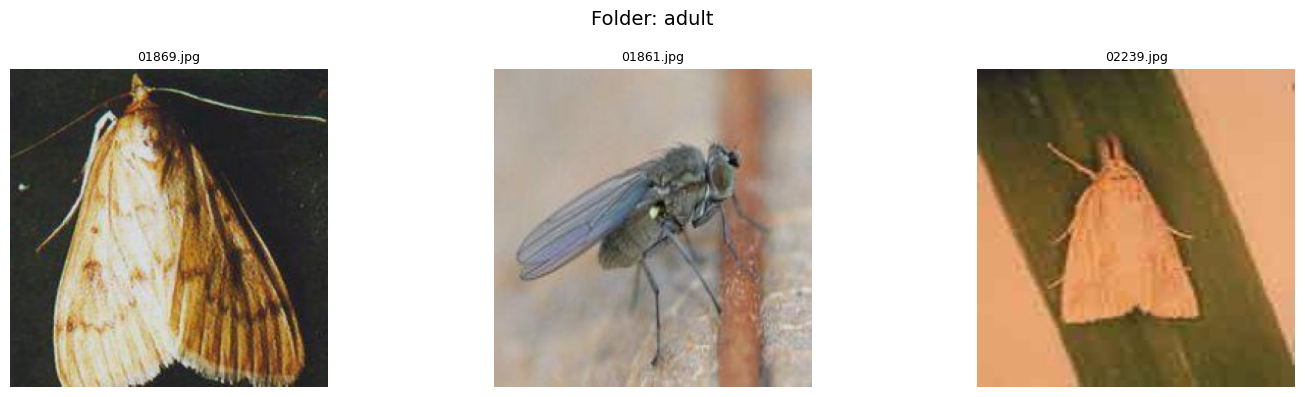

Folder: /content/drive/MyDrive/Pest_V2/asiatic rice borer/larva
Found: 319 images


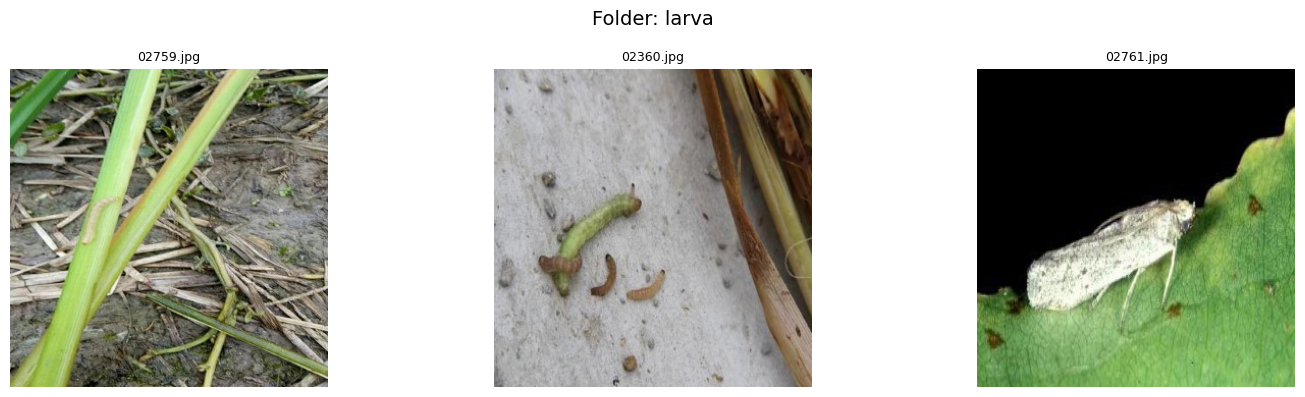

Folder: /content/drive/MyDrive/Pest_V2/rice leaf roller/egg
Found: 3 images


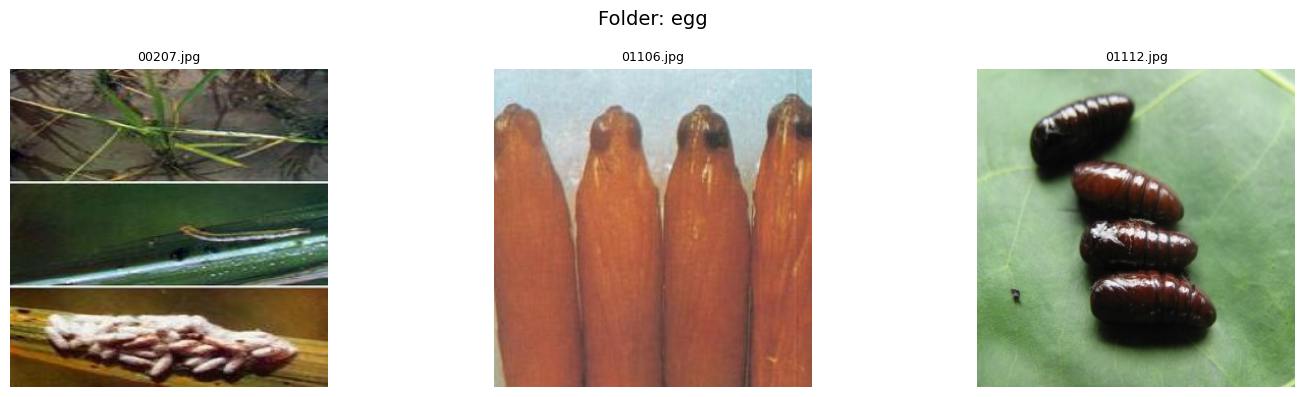

Folder: /content/drive/MyDrive/Pest_V2/rice leaf roller/adult
Found: 152 images


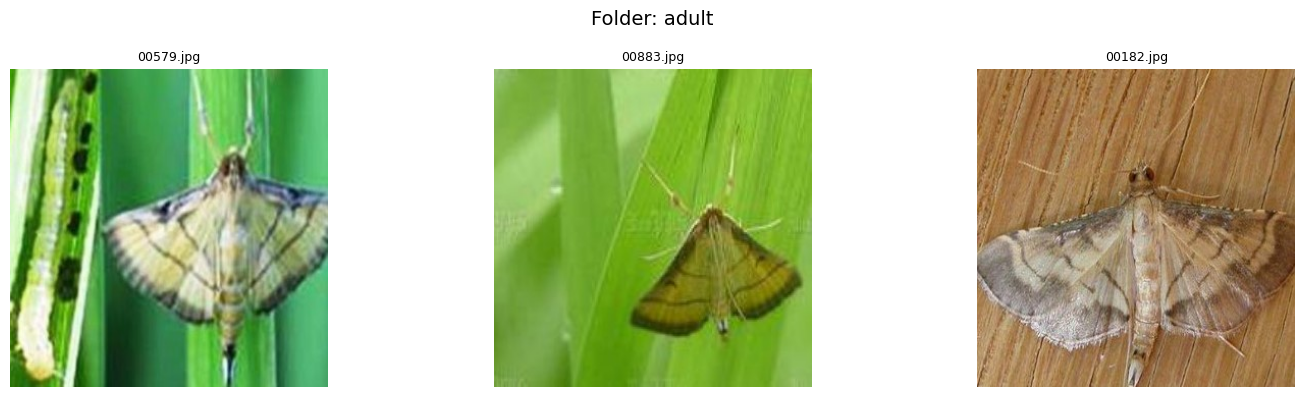

Folder: /content/drive/MyDrive/Pest_V2/rice leaf roller/larva
Found: 562 images


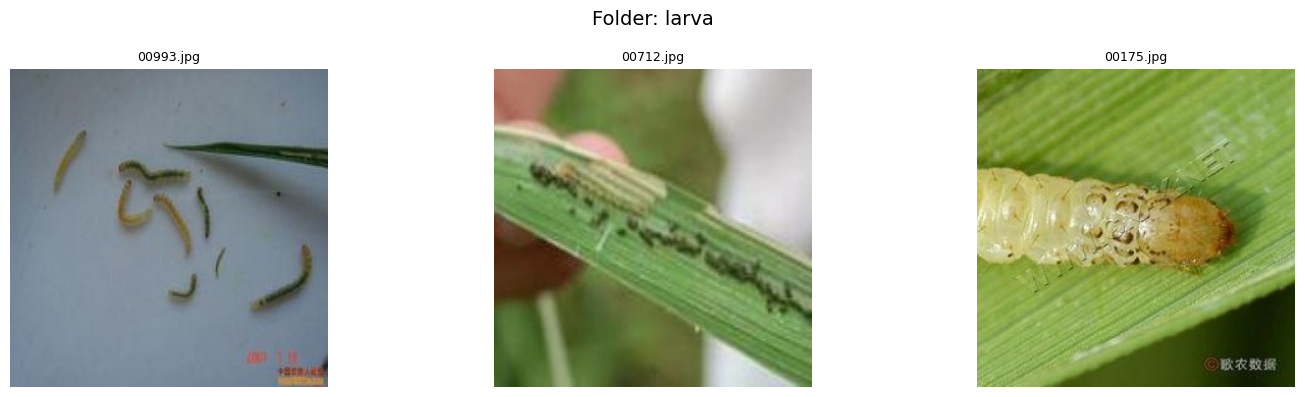

In [18]:
from PIL import Image

# Path to the main directory containing multiple subfolders
subfolders = sorted([f.path for f in os.scandir(base_path) if f.is_dir()])

# Set max images to show per row
max_images = 3

for dirname, _, filenames in os.walk('/content/drive/MyDrive/Pest_V2'):
    if not filenames:
        continue
    image_files = [f for f in filenames if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
    if not image_files:
        continue
    print(f"Folder: {dirname}")
    print(f"Found: {len(image_files)} images")
    to_show = image_files[:max_images]

    fig, axes = plt.subplots(1, len(to_show), figsize=(15, 4))
    fig.suptitle(f"Folder: {os.path.basename(dirname)}", fontsize=14)
    for i, filename in enumerate(to_show):
      img_path = os.path.join(dirname, filename)
      try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(filename, fontsize=9)
            axes[i].axis('off')

      except Exception as e:
            print(f"Error loading {filename}: {e}")
            axes[i].text(0.5, 0.5, "Error", ha='center')
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()
